연습 문제

In [1]:
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
from math import sqrt

# 가정 확인을 위한 라이브러리
from scipy.stats import t, normaltest, bartlett, levene

# 분산분석을 위한 라이브러리
from pingouin import anova
from pingouin import welch_anova

# 사후검정을 위한 라이브러리
from pingouin import pairwise_tukey, pairwise_gameshowell

In [2]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath)  # 폰트의 속성을 읽어옴
fname = fprop.get_name()  # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams["font.family"] = fname
plt.rcParams["font.size"] = 10
plt.rcParams["axes.unicode_minus"] = False

In [3]:
origin = load_data("poisons")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/poisons.xlsx
[desc] 독극물 종류별로 동물의 생존시간을 기록한 실험 데이터 (출처: 방송통신대학교 통계학 개론)

field    description
-------  ------------------
time     동물의 생존시간
poison   사용된 독극물 종류
treat    사용되는 치료 유형


===== 데이터 크기 확인 =====
데이터셋 크기: (360, 3)
열 개수: 3
행 개수: 360

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    360 non-null    float64
 1   poison  360 non-null    object 
 2   treat   360 non-null    object 
dtypes: float64(1), object(2)
memory usage: 8.6+ KB
None


,time,poison,treat
0,3.8,P1,T1
1,2.7,P1,T1
2,1.7,P1,T1
3,2.2,P1,T1
4,0.7,P1,T1


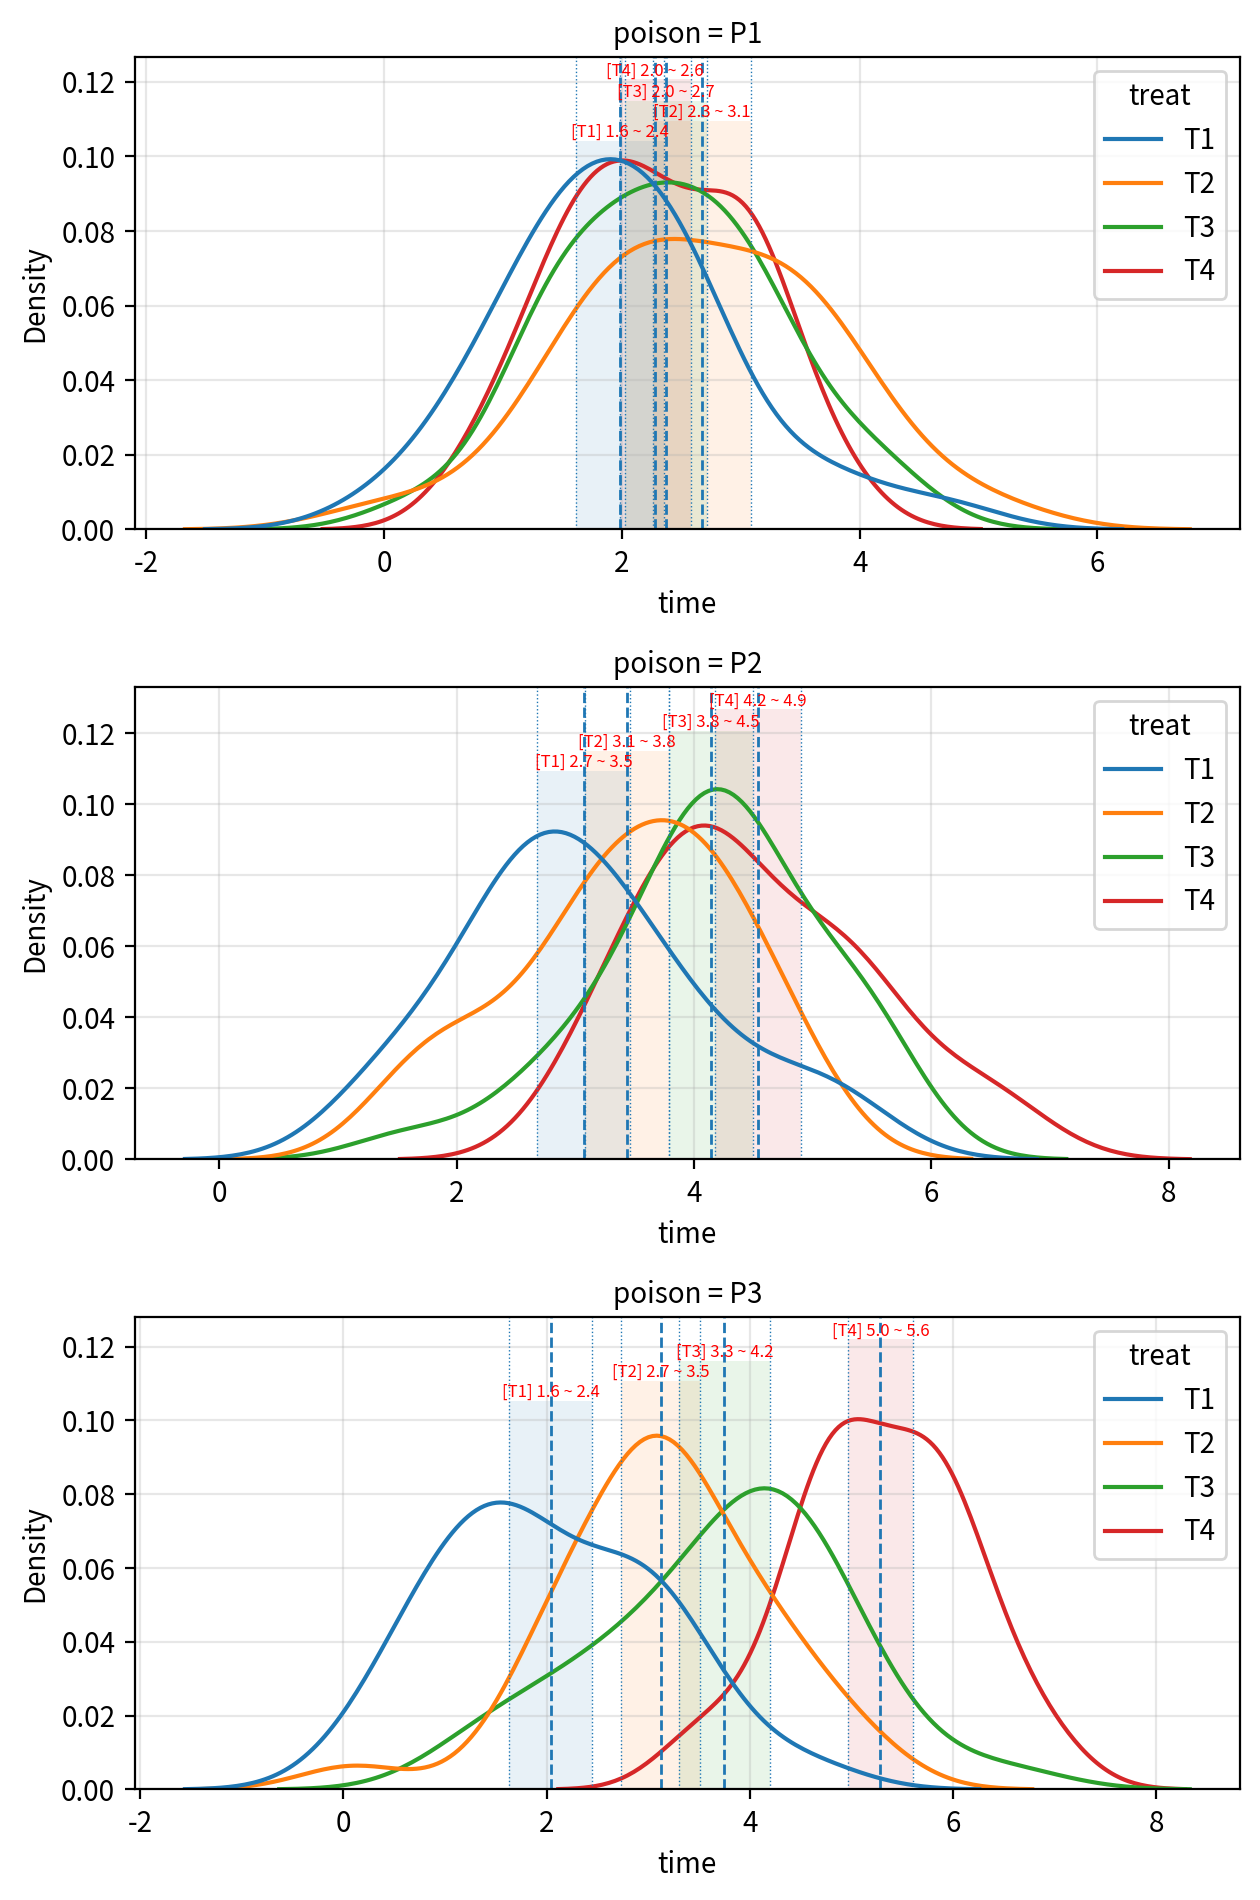

In [4]:
# sqrt, t, sb, plt, my_dpi, origin 이 이미 준비되어 있다고 가정합니다.
field = "time"  # 예: 'height'
group_field = "poison"  # 예: 'water'
hue_field = "treat"  # 예: 'sun'

# 시각화 할 필드만 원본 데이터에서 추출
data = origin[[field, group_field, hue_field]].dropna()
group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()

# 1) 그래프 초기화
rows = group_count  # 그래프 행 수
cols = 1  # 그래프 열 수
width_px = 1280 * cols  # 그래프 가로 크기
height_px = 640 * rows  # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# rows가 1이면 ax가 단일 객체이므로 리스트로 변환
axes = ax if rows > 1 else [ax]

# 2) 그래프 그리기
for i, v in enumerate(group_values):
    # 그룹별 데이터 필터링
    temp = data[data[group_field] == v]

    # KDE Plot
    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=axes[i])
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title(f"{group_field} = {v}", fontsize=10, pad=5)

    for h in hue_values:
        temp_sub = temp[temp[hue_field] == h]

        # 신뢰구간 계산
        max_val = temp_sub[field].max()  # 최대값 (필요시 사용)
        clevel = 0.95  # 신뢰수준
        dof = len(temp_sub[field]) - 1  # 자유도
        sp_mean = temp_sub[field].mean()  # 표본평균
        sp_std = temp_sub[field].std(ddof=1)  # 표본표준편차
        sp_std_error = sp_std / sqrt(len(temp_sub[field]))  # 표본표준오차

        cmin, cmax = t.interval(clevel, dof, loc=sp_mean, scale=sp_std_error)

        # 신뢰구간 경계선
        axes[i].axvline(cmin, linestyle=":", linewidth=0.5)
        axes[i].axvline(cmax, linestyle=":", linewidth=0.5)

        # 평균 및 신뢰구간 영역 표시
        ymin, ymax = axes[i].get_ylim()
        axes[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        axes[i].axvline(sp_mean, linestyle="--", linewidth=1)

        # 텍스트 그리기
        axes[i].text(
            x=(cmax - cmin) / 2 + cmin,
            y=ymax,
            s="[%s] %0.1f ~ %0.1f" % (h, cmin, cmax),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"},
        )

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

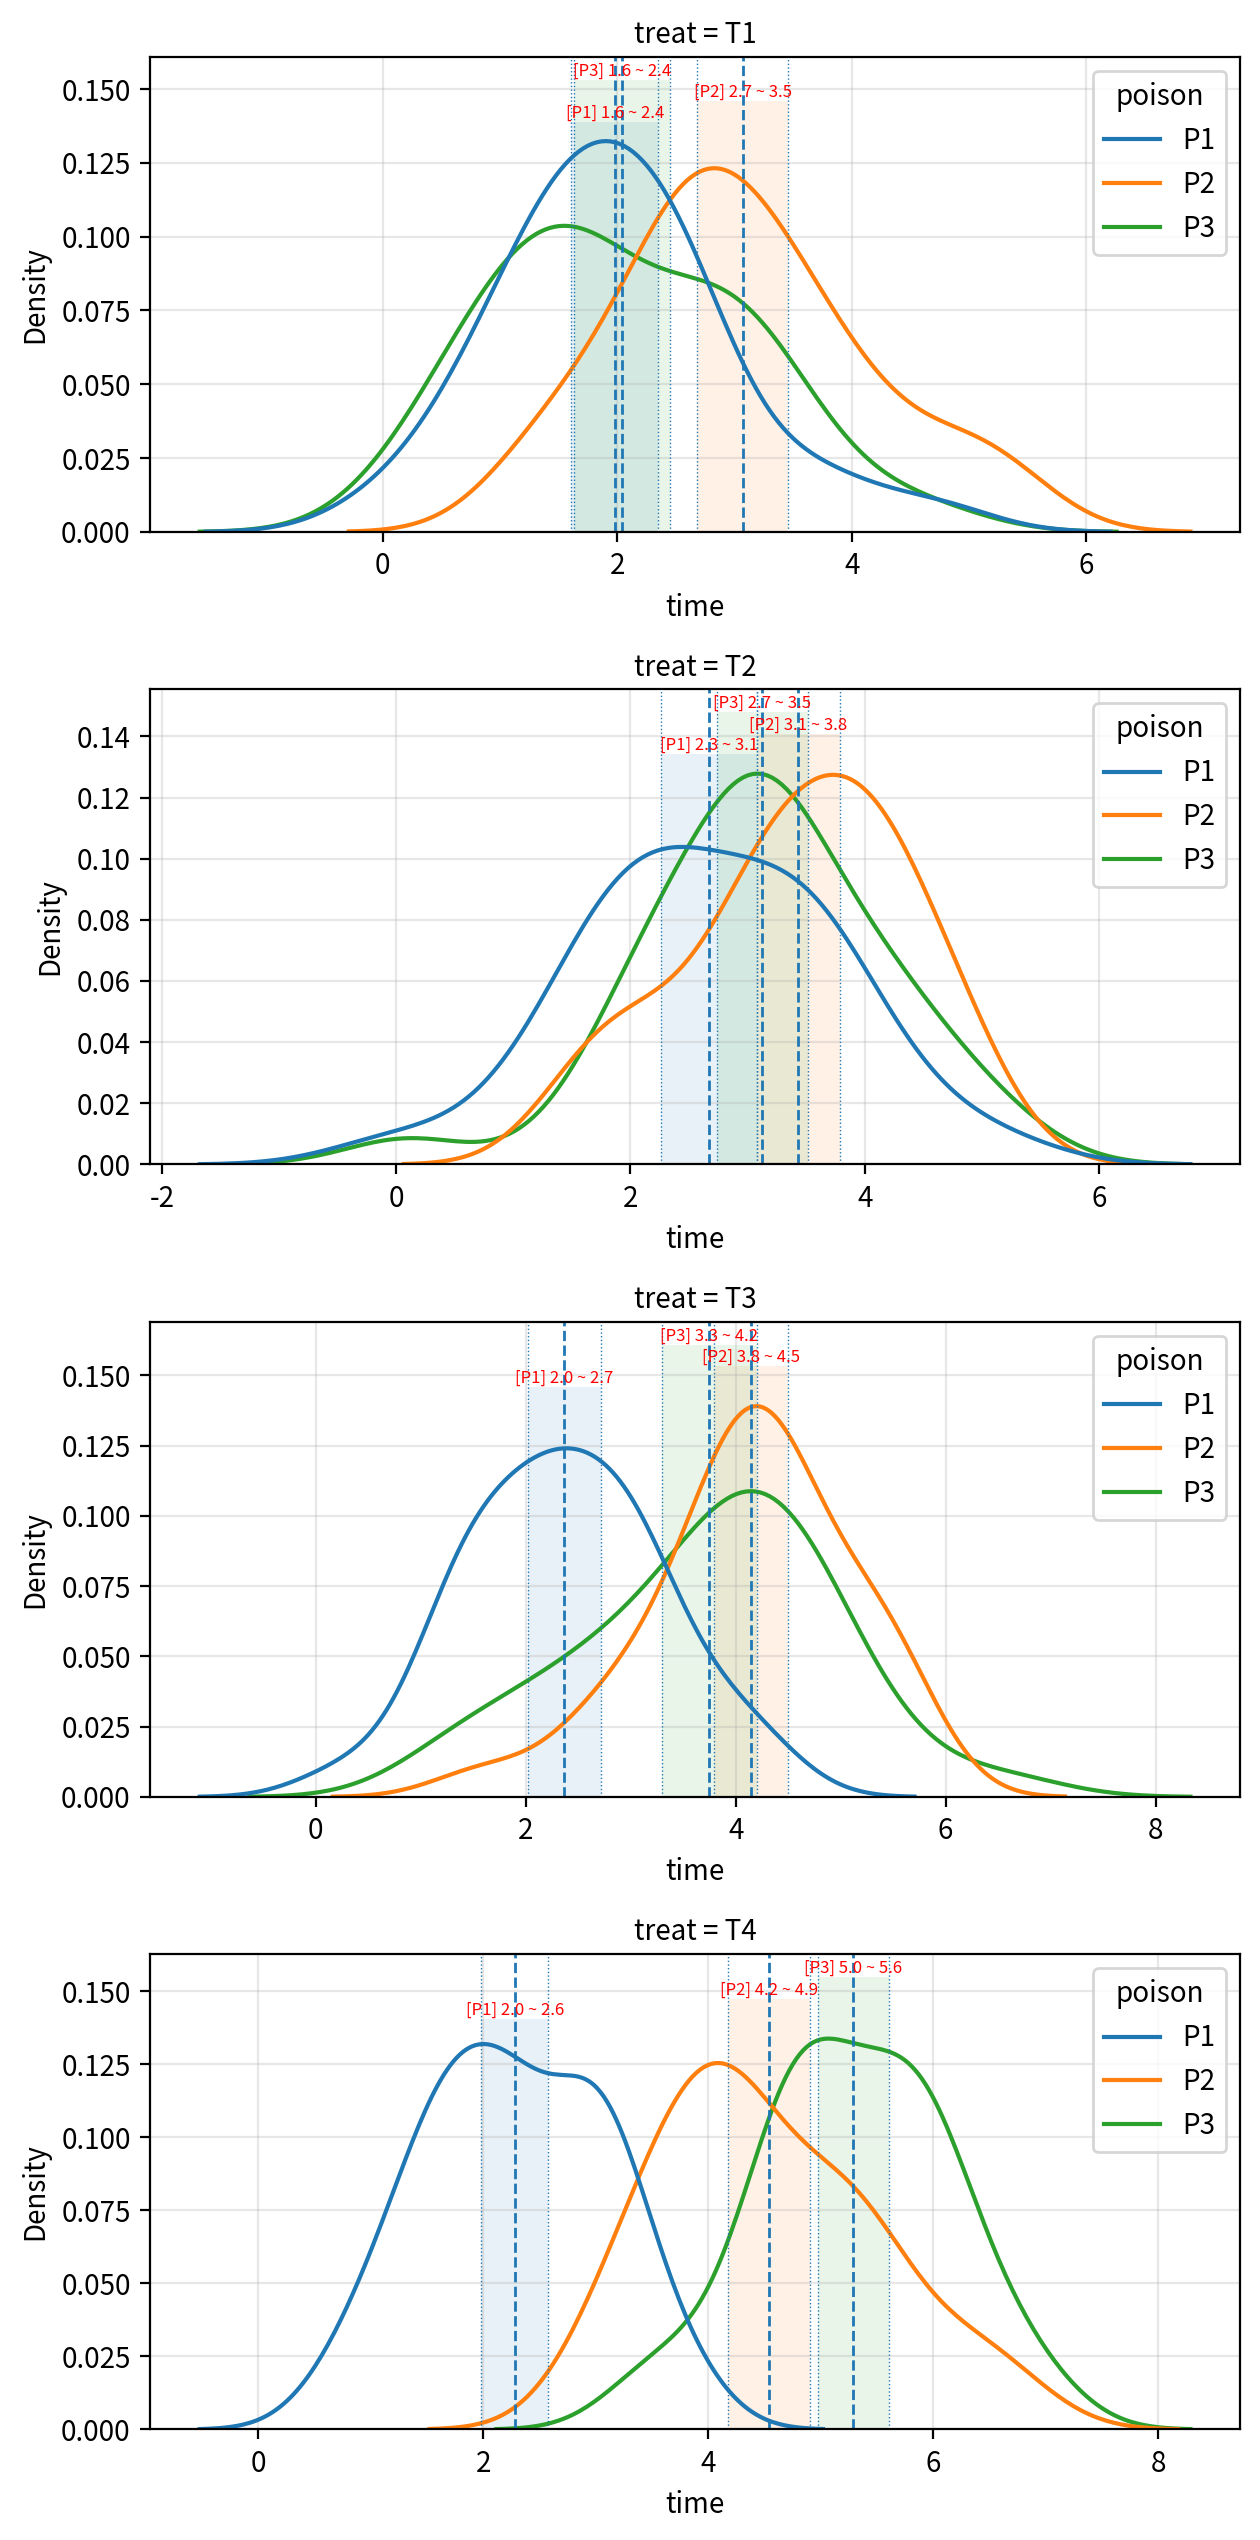

In [5]:
field = "time"  # 예: 'height'
group_field = "treat"  # 예: 'water'
hue_field = "poison"  # 예: 'sun'

# 시각화 할 필드만 원본 데이터에서 추출
data = origin[[field, group_field, hue_field]].dropna()
group_values = data[group_field].unique()
group_count = len(group_values)
hue_values = data[hue_field].unique()

# 1) 그래프 초기화
rows = group_count  # 그래프 행 수
cols = 1  # 그래프 열 수
width_px = 1280 * cols  # 그래프 가로 크기
height_px = 640 * rows  # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# rows가 1이면 ax가 단일 객체이므로 리스트로 변환
axes = ax if rows > 1 else [ax]

# 2) 그래프 그리기
for i, v in enumerate(group_values):
    # 그룹별 데이터 필터링
    temp = data[data[group_field] == v]

    # KDE Plot
    sb.kdeplot(data=temp, x=field, hue=hue_field, ax=axes[i])
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title(f"{group_field} = {v}", fontsize=10, pad=5)

    for h in hue_values:
        temp_sub = temp[temp[hue_field] == h]

        # 신뢰구간 계산
        max_val = temp_sub[field].max()  # 최대값 (필요시 사용)
        clevel = 0.95  # 신뢰수준
        dof = len(temp_sub[field]) - 1  # 자유도
        sp_mean = temp_sub[field].mean()  # 표본평균
        sp_std = temp_sub[field].std(ddof=1)  # 표본표준편차
        sp_std_error = sp_std / sqrt(len(temp_sub[field]))  # 표본표준오차

        cmin, cmax = t.interval(clevel, dof, loc=sp_mean, scale=sp_std_error)

        # 신뢰구간 경계선
        axes[i].axvline(cmin, linestyle=":", linewidth=0.5)
        axes[i].axvline(cmax, linestyle=":", linewidth=0.5)

        # 평균 및 신뢰구간 영역 표시
        ymin, ymax = axes[i].get_ylim()
        axes[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
        axes[i].axvline(sp_mean, linestyle="--", linewidth=1)

        # 텍스트 그리기
        axes[i].text(
            x=(cmax - cmin) / 2 + cmin,
            y=ymax,
            s="[%s] %0.1f ~ %0.1f" % (h, cmin, cmax),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"},
        )

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

In [7]:
data = origin.copy()

xname = ["poison", "treat"]  # 두 개의 요인(범주형 변수, 예: 'water', 'sun')
yname = "time"  # 종속 변수, 예: 'height'

u1 = data[xname[0]].unique()
u2 = data[xname[1]].unique()

equal_var_fields = []
normal_dist = True
report = []

for i in u1:
    for j in u2:
        # 두 요인의 조합별로 데이터 필터링
        filtered_data = data[(data[xname[0]] == i) & (data[xname[1]] == j)][
            yname
        ].dropna()

        # 데이터가 없으면 스킵
        if len(filtered_data) == 0:
            continue

        equal_var_fields.append(filtered_data)

        # 정규성 검정
        s, p = normaltest(filtered_data)
        normalize = p > 0.05

        report.append(
            {
                "field": "{0}={1}, {2}={3}".format(xname[0], i, xname[1], j),
                "statistic": s,
                "p-value": p,
                "result": normalize,
            }
        )

        normal_dist = normal_dist and normalize

# 전체 그룹들이 모두 정규성을 만족하는지에 따라 등분산 검정 선택
if normal_dist:
    n = "Bartlett"
    s, p = bartlett(*equal_var_fields)
else:
    n = "Levene"
    s, p = levene(*equal_var_fields)

equal_var = p > 0.05  # 필요하면 따로 사용

report.append({"field": n, "statistic": s, "p-value": p, "result": p > 0.05})

report_df = DataFrame(report).set_index("field")
report_df

,statistic,p-value,result
field,,,
"poison=P1, treat=T1",3.660816,0.160348,True
"poison=P1, treat=T2",0.266462,0.875263,True
"poison=P1, treat=T3",0.014374,0.992839,True
"poison=P1, treat=T4",1.476194,0.478023,True
"poison=P2, treat=T1",1.112279,0.573418,True
"poison=P2, treat=T2",1.509951,0.470022,True
"poison=P2, treat=T3",2.802084,0.246340,True
"poison=P2, treat=T4",1.662054,0.435602,True
"poison=P3, treat=T1",0.837473,0.657878,True


In [9]:
xname = ["treat", "poison"]
yname = "time"

data = origin[xname + [yname]]

levels = {}  # 빈 딕셔너리 만들기
# 예: {'water': 2, 'sun': 3} 이런 식 결과
for factor in xname:  # 요인을 하나씩 꺼냄
    level_count = data[factor].nunique()  # 요인의 수준 수 계산
    levels[factor] = level_count  # 딕셔너리에 저장

pvals = {}  # 빈 딕셔너리 만들기
# 예: {'water': 1.30e-20, 'sun': 2.01e-17, 'water * sun': 0.105}
for index, row in pg_anova.iterrows():  # 행을 하나씩 꺼냄
    source_name = row["Source"]  # 요인 이름
    p_value = row["p-unc"]  # 각 요인의 p-value
    pvals[source_name] = p_value  # 딕셔너리에 저장

# 주효과 사후검정
for factor in xname:
    print(f"\n[{factor}]")

    # 수준이 2개면 사후검정 필요 없음
    if levels[factor] == 2:
        print(f"- {levels[factor]}수준 요인이므로 사후검정이 필요 없습니다.")
        continue

    p_val = pvals.get(factor, None)
    if p_val is None:
        print("- ANOVA 결과에서 해당 요인을 찾을 수 없습니다.")
        continue

    if p_val > 0.05:
        print(f"- 주효과 유의하지 않음 (p={p_val:.3g}) → 사후검정 수행 안 함")
        continue

    print(f"- 주효과 유의 (p={p_val:.3g}) → 사후검정 수행")

    if equal_var:
        print(" · Tukey HSD 사용 (등분산 충족)")
        hoc_df = pairwise_tukey(data=data, dv=yname, between=factor)
    else:
        print(" · Games–Howell 사용 (등분산 불충족)")
        hoc_df = pairwise_gameshowell(data=data, dv=yname, between=factor)

    display(hoc_df)

# 상호작용 자동 처리
interaction_names = [src for src in pvals.keys() if "*" in src]

for inter in interaction_names:
    p_val = pvals[inter]
    print(f"\n[{inter}] 상호작용 효과")

    if p_val <= 0.05:
        print(f"- 상호작용 유의 (p={p_val:.3g}) → 단순주효과 분석 필요")
    else:
        print(f"- 상호작용 유의하지 않음 (p={p_val:.3g}) → 단순주효과 분석 필요 없음")


[treat]
- 주효과 유의 (p=4.43e-24) → 사후검정 수행
 · Tukey HSD 사용 (등분산 충족)


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,T1,T2,2.363333,3.075556,-0.712222,0.189827,-3.751957,1.168920e-03,-0.639750
1,T1,T3,2.363333,3.421111,-1.057778,0.189827,-5.572330,2.971229e-07,-0.867932
2,T1,T4,2.363333,4.034444,-1.671111,0.189827,-8.803345,0.000000e+00,-1.220199
3,T2,T3,3.075556,3.421111,-0.345556,0.189827,-1.820373,2.654092e-01,-0.292572
4,T2,T4,3.075556,4.034444,-0.958889,0.189827,-5.051387,4.181336e-06,-0.717648
5,T3,T4,3.421111,4.034444,-0.613333,0.189827,-3.231015,7.343056e-03,-0.430346



[poison]
- 주효과 유의 (p=1e-27) → 사후검정 수행
 · Tukey HSD 사용 (등분산 충족)


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,P1,P2,2.325000,3.795833,-1.470833,0.161626,-9.100235,0.000000e+00,-1.388884
1,P1,P3,2.325000,3.550000,-1.225000,0.161626,-7.579233,8.463230e-13,-0.931693
2,P2,P3,3.795833,3.550000,0.245833,0.161626,1.521002,2.822579e-01,0.179210



[poison * treat] 상호작용 효과
- 상호작용 유의 (p=6.94e-14) → 단순주효과 분석 필요


📝 1. 분석 목적

본 분석은 동물의 생존시간에 대해 사용된 독극물 종류와 사용되는 치료 유형이 어떠한 영향을 미치는지를 검증하기 위해 이원분산분석(two-way-ANOVA)을 수행하였다.

📝 2. 분산분석 주요 결과
2-1. 요인별 유의성 판단
- 요인1: F = F값, p = p값, ηp² = 효과크기 → 유의성 판단
- 요인2: F = F값, p = p값, ηp² = 효과크기 → 유의성 판단
- 상호작용: F = F값, p = p값, ηp² = 효과크기 → 유의성 판단
(**요약:**) 핵심 요약문 1–2문장

📝 3. 기술통계 및 집단별 평균 비교
- 요인1 수준별 평균: 설명
- 요인2 수준별 평균: 설명
- 상호작용 조합 평균(해당 시): 설명
(**요약 해석:**) 패턴 설명

📝 4. 사후검정(Post-hoc) 결과
- 요인1: 수준 수수준 → 사후검정 여부 및 이유
- 요인2: 사후검정 결과 요약
- 상호작용(simple effects): 필요 여부
(**요약 해석:**) 사후검정으로 확인된 구체적 차이

📝 5. 최종 결론 요약
- • 핵심 인사이트 1
- • 핵심 인사이트 2
- • 핵심 인사이트 3
- • 모형의 의미 있는 해석
(**최종 한 문장 결론:**) DV는 주요 요인의 영향을 크게 받으며, 상호작용 여부가 확인되었다.